## 05 · XGBoost & LightGBM

**Goals**
1. Run the full feature-engineering pipeline and create the time-aware split.
2. Train **XGBoost** with early stopping on the validation set.
3. Train **LightGBM** with the same feature set.
4. Evaluate both models and compare feature importances.
5. Save the best model for the final evaluation notebook.

---
Both models receive the same 24 features at the per-store-department level.

> **Install**: `pip install xgboost lightgbm`

In [2]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.data_loader   import load_raw_data, merge_datasets
from src.preprocessing import full_pipeline, time_based_split
from src.models        import (get_xgboost, get_lgbm,
                                evaluate_model, calc_metrics,
                                plot_feature_importance, plot_residuals)
from src.config        import MODEL_FEATURES, XGB_FILE, LGBM_FILE, PRIMARY_COLOR, SECONDARY_COLOR

plt.rcParams["figure.dpi"] = 110
print("Imports OK")

Imports OK


---
## 1 · Load Data & Feature Engineering

In [3]:
train_df, features_df, stores_df = load_raw_data()
df_raw = merge_datasets(train_df, features_df, stores_df)

print("\nRunning feature engineering pipeline...")
df = full_pipeline(df_raw)

train_df    : 421,570 rows × 5 cols
features_df :   8,190 rows × 12 cols
stores_df   :      45 rows × 3 cols
Dropped MarkDown columns (>50% missing): ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
Merged shape : 421,570 rows × 11 cols
Date range   : 2010-02-05 → 2012-10-26

Running feature engineering pipeline...
Step 1/6 — Fill missing externals
Step 2/6 — Time features
Step 3/6 — Holiday flags
Step 4/6 — Store type encoding
Step 5/6 — Lag features
  Sales_Lag_1
  Sales_Lag_4
  Sales_Lag_8
  Sales_Lag_52
Step 6/6 — Rolling statistics
  Sales_MA_4, Sales_STD_4
  Sales_MA_8, Sales_STD_8
  Sales_MA_12, Sales_STD_12

Pipeline complete. Shape: 421,570 rows × 32 cols


In [4]:
print("Time-based split:")
X_train, X_val, X_test, y_train, y_val, y_test = time_based_split(df)

print(f"\nFeature count : {X_train.shape[1]}")
print(f"\nTarget stats (y_train):")
print(y_train.describe().round(2).to_string())

Time-based split:
Train : 197,201 samples  2011-02-04 – 2012-05-25
Val   :  26,017 samples  2012-06-01 – 2012-07-27
Test  :  37,865 samples  2012-08-03 – 2012-10-26

Feature count : 24

Target stats (y_train):
count    197201.00
mean      16484.52
std       22982.95
min       -1321.48
25%        2422.46
50%        8031.69
75%       20771.37
max      649770.18


---
## 2 · XGBoost

In [5]:
xgb = get_xgboost(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
)

print("Training XGBoost...")
xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100,
)
print(f"\nBest iteration: {xgb.best_iteration}")

Training XGBoost...
[0]	validation_0-rmse:21881.09947	validation_1-rmse:21142.75057
[100]	validation_0-rmse:2568.54037	validation_1-rmse:2419.22412
[200]	validation_0-rmse:2189.06725	validation_1-rmse:2371.29357
[300]	validation_0-rmse:2002.23646	validation_1-rmse:2337.72149
[400]	validation_0-rmse:1864.53048	validation_1-rmse:2299.62241
[499]	validation_0-rmse:1766.66970	validation_1-rmse:2272.64047

Best iteration: 499


In [6]:
xgb_metrics = evaluate_model(xgb, X_train, y_train, X_val, y_val, X_test, y_test,
                              model_name="XGBoost")

xgb_test_pred = xgb.predict(X_test)
xgb_val_pred  = xgb.predict(X_val)


════════════════════════════════════════════════════════════
  XGBoost  —  Evaluation
════════════════════════════════════════════════════════════
  Set      RMSE       MAE     R2  MAPE(%)
Train 1766.6697  969.3880 0.9941 277.1138
  Val 2272.6404 1068.2311 0.9896 240.4063
 Test 2176.1974 1016.5092 0.9903  99.4489


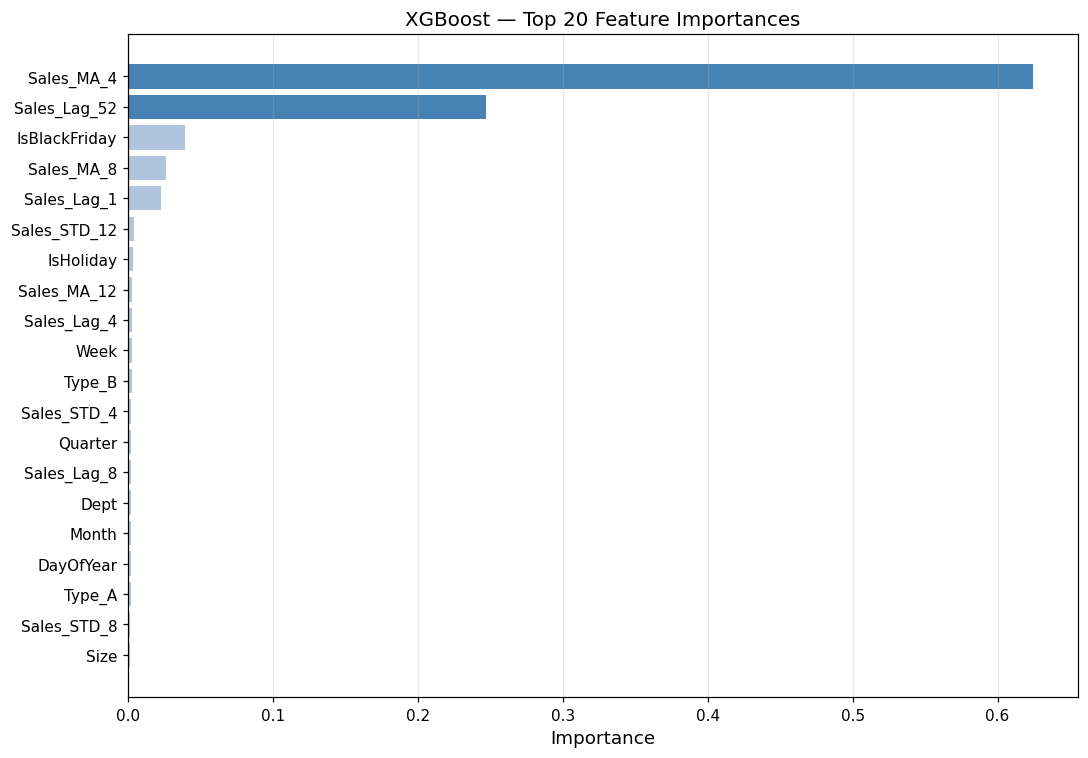

In [7]:
plot_feature_importance(
    xgb, list(X_train.columns),
    top_n=20, title="XGBoost — Top 20 Feature Importances"
)

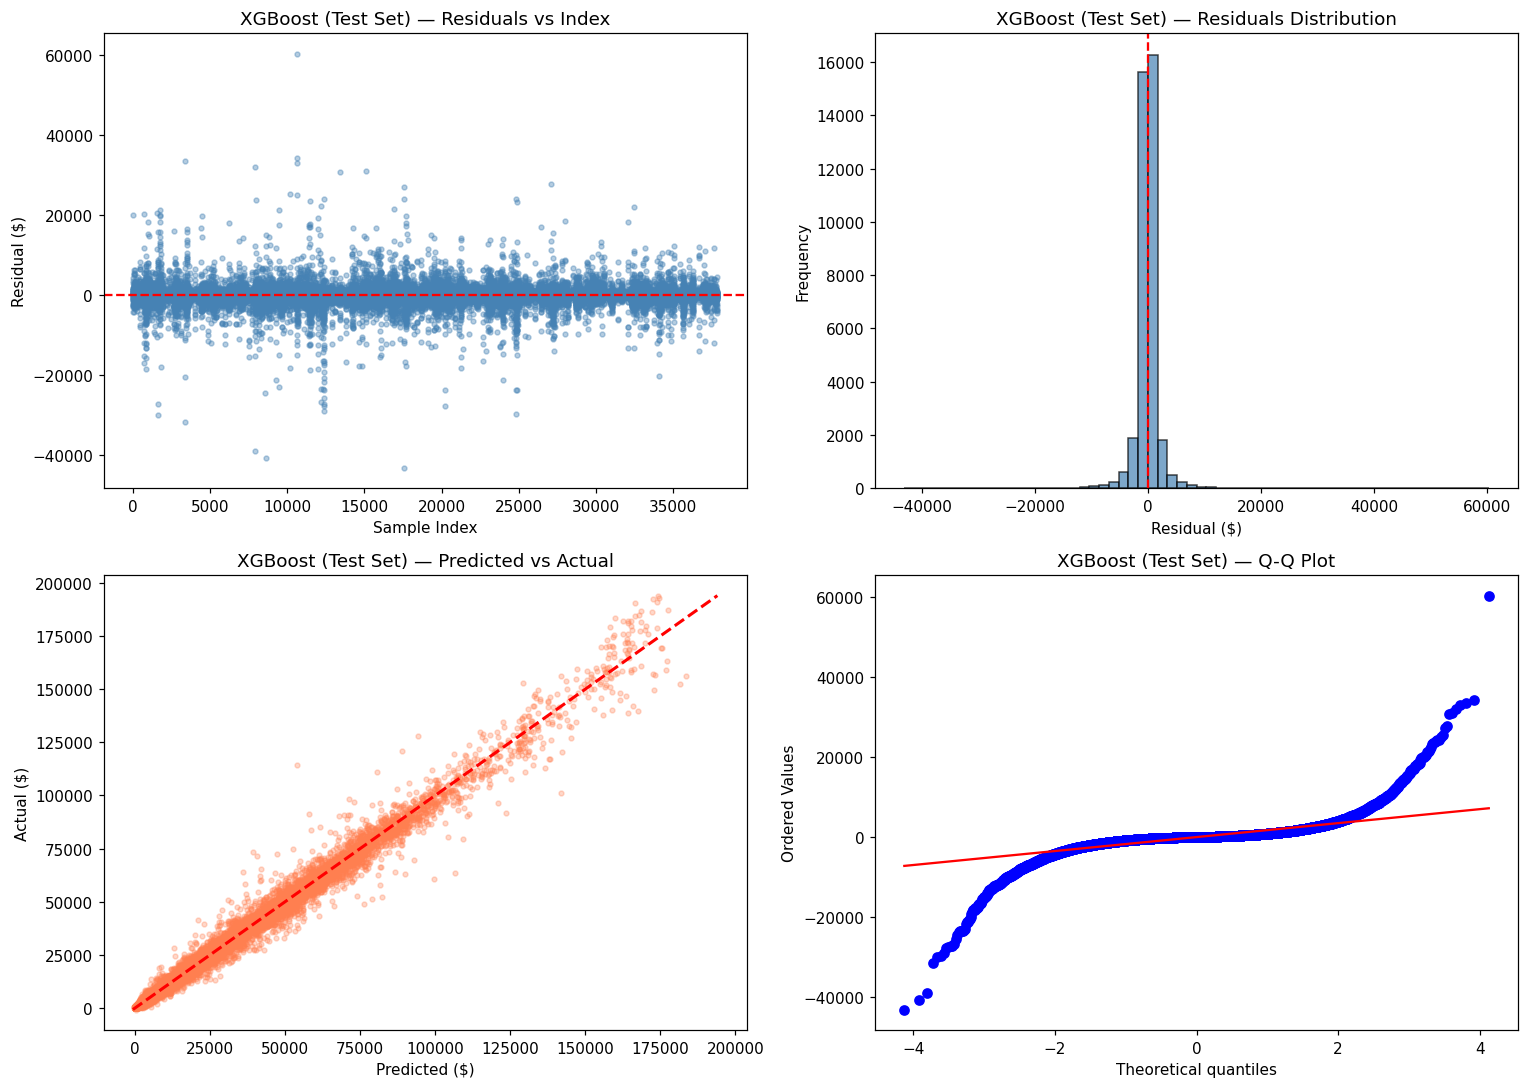

In [8]:
plot_residuals(y_test, xgb_test_pred, title_prefix="XGBoost (Test Set)")

---
## 3 · LightGBM

In [9]:
try:
    lgbm = get_lgbm(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
    )

    print("Training LightGBM...")
    lgbm.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            __import__("lightgbm").early_stopping(50, verbose=False),
            __import__("lightgbm").log_evaluation(100),
        ],
    )
    lgbm_available = True
    print("\nLightGBM training complete. ✓")

except ImportError:
    lgbm_available = False
    print("LightGBM not installed. Skipping. (pip install lightgbm)")

Training LightGBM...
[100]	valid_0's l2: 5.81612e+06
[200]	valid_0's l2: 5.51103e+06
[300]	valid_0's l2: 5.35701e+06
[400]	valid_0's l2: 5.1678e+06
[500]	valid_0's l2: 5.04401e+06

LightGBM training complete. ✓


In [10]:
if lgbm_available:
    lgbm_metrics = evaluate_model(lgbm, X_train, y_train, X_val, y_val, X_test, y_test,
                                  model_name="LightGBM")

    lgbm_test_pred = lgbm.predict(X_test)
    lgbm_val_pred  = lgbm.predict(X_val)
else:
    lgbm_metrics = None
    lgbm_test_pred = None


════════════════════════════════════════════════════════════
  LightGBM  —  Evaluation
════════════════════════════════════════════════════════════
  Set      RMSE       MAE     R2  MAPE(%)
Train 1971.1186  990.1067 0.9926 229.4513
  Val 2245.8770 1055.9525 0.9898 196.9226
 Test 2176.5981 1017.9315 0.9902  78.3929


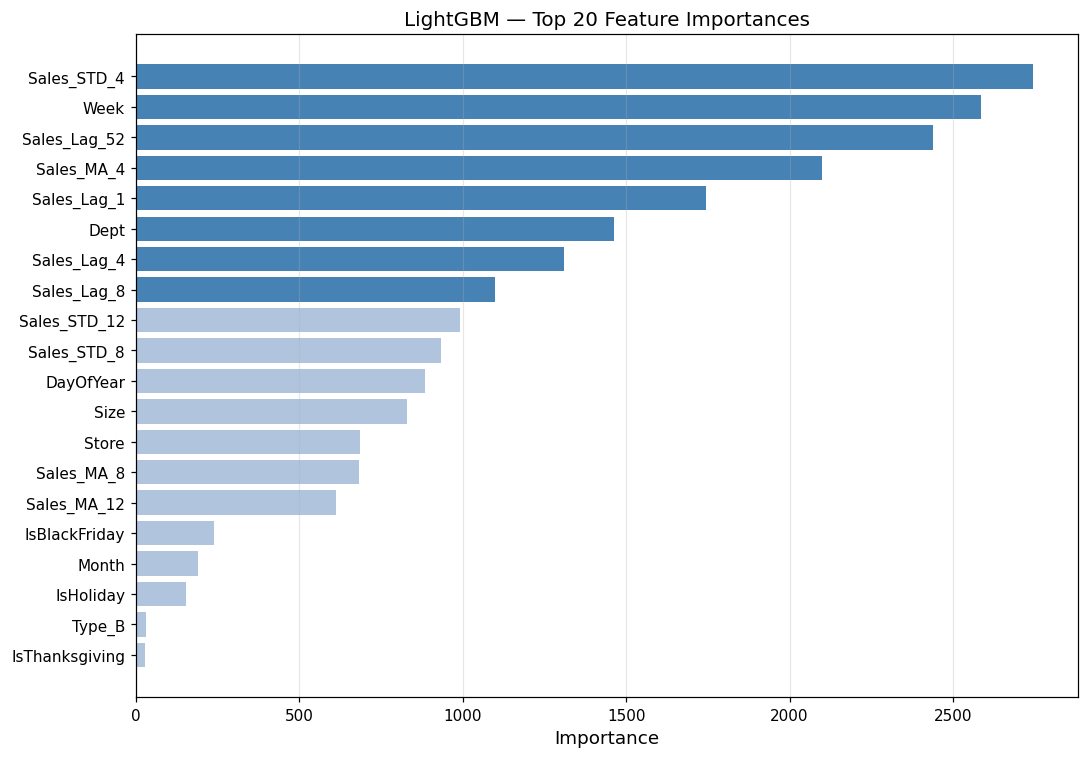

In [11]:
if lgbm_available:
    plot_feature_importance(
        lgbm, list(X_train.columns),
        top_n=20, title="LightGBM — Top 20 Feature Importances"
    )

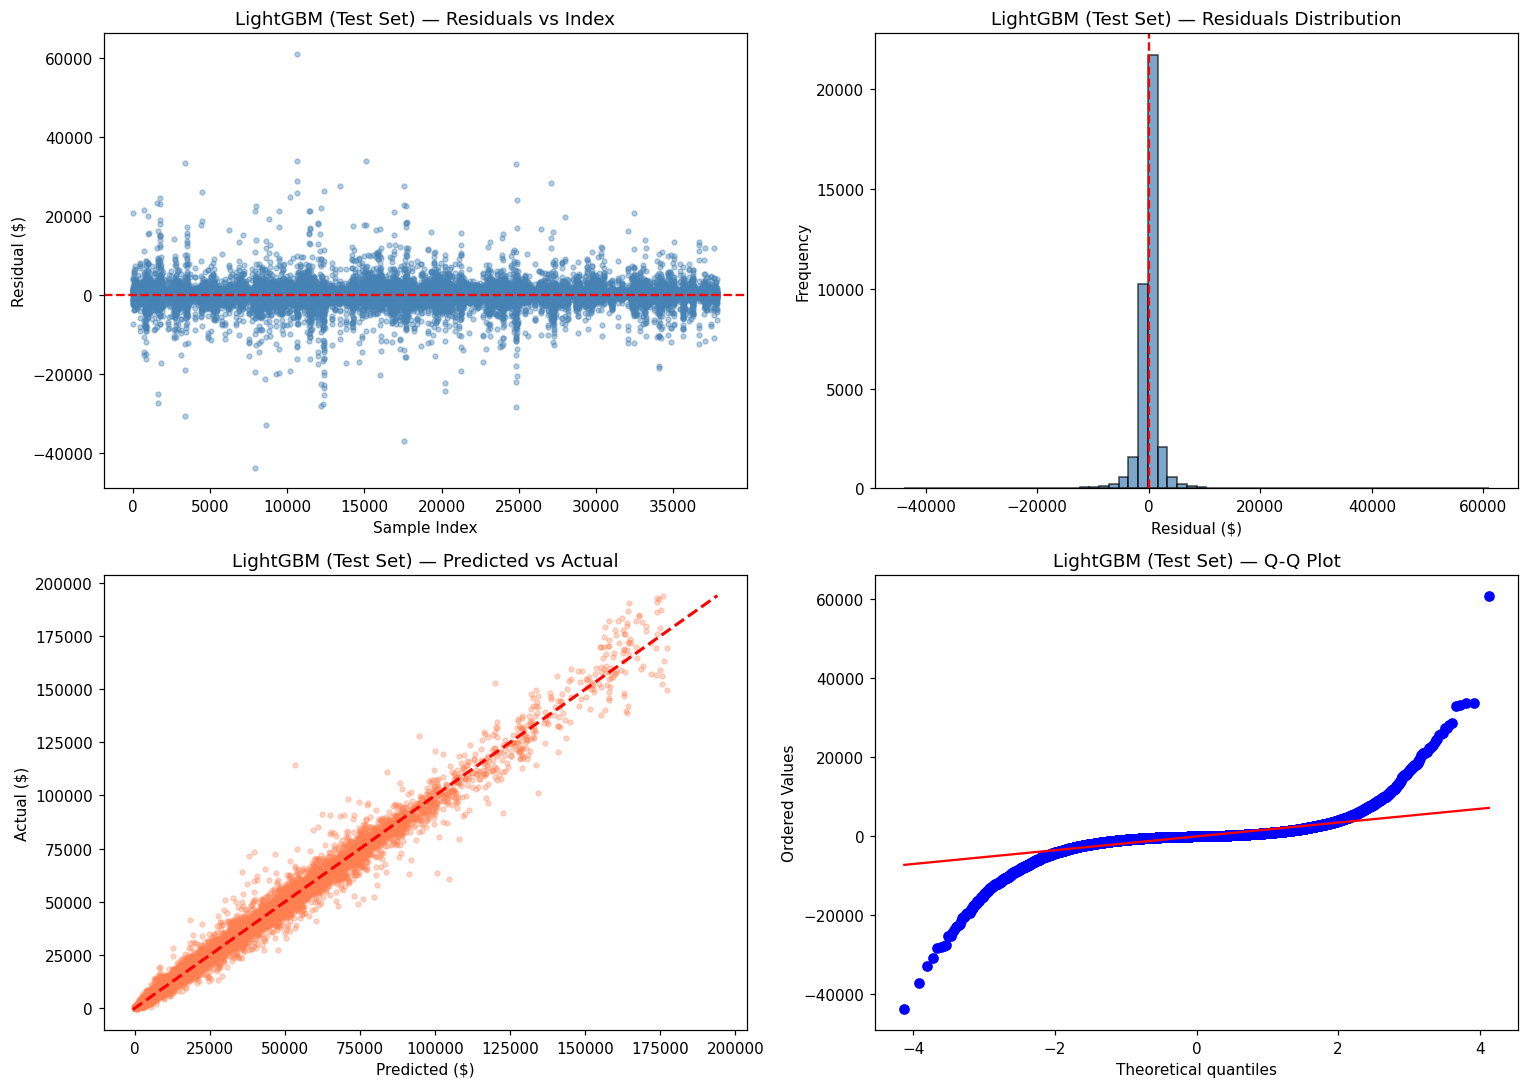

In [12]:
if lgbm_available:
    plot_residuals(y_test, lgbm_test_pred, title_prefix="LightGBM (Test Set)")

---
## 4 · XGBoost vs LightGBM Side-by-Side

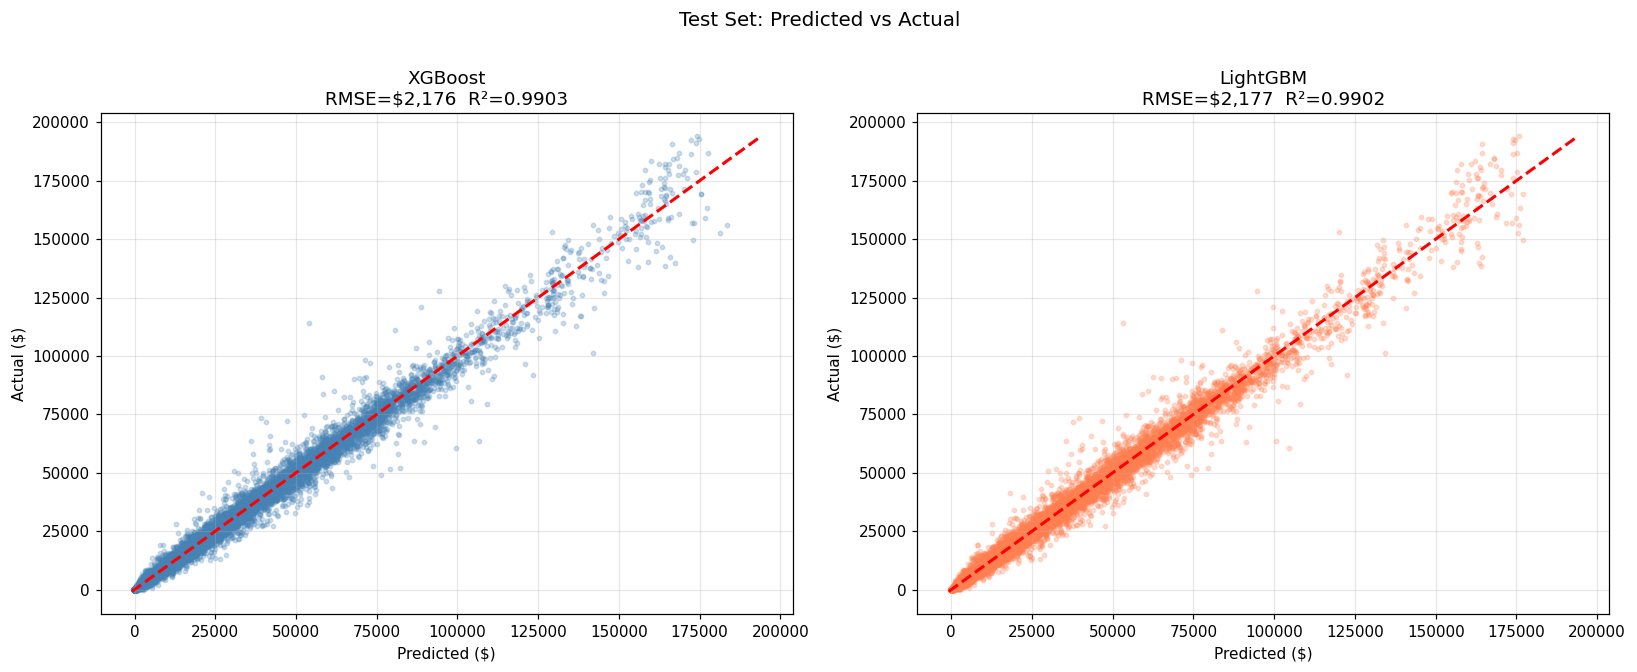

In [13]:
if lgbm_available:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, pred, name, color in zip(
        axes,
        [xgb_test_pred, lgbm_test_pred],
        ["XGBoost", "LightGBM"],
        [PRIMARY_COLOR, SECONDARY_COLOR],
    ):
        m = calc_metrics(y_test, pred)
        lo = min(y_test.min(), pred.min())
        hi = max(y_test.max(), pred.max())
        ax.scatter(pred, y_test, alpha=0.25, s=8, color=color)
        ax.plot([lo, hi], [lo, hi], "r--", lw=2)
        ax.set_title(f"{name}\nRMSE=${m['RMSE']:,.0f}  R²={m['R2']:.4f}", fontsize=12)
        ax.set_xlabel("Predicted ($)", fontsize=10)
        ax.set_ylabel("Actual ($)", fontsize=10)
        ax.grid(alpha=0.3)

    plt.suptitle("Test Set: Predicted vs Actual", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

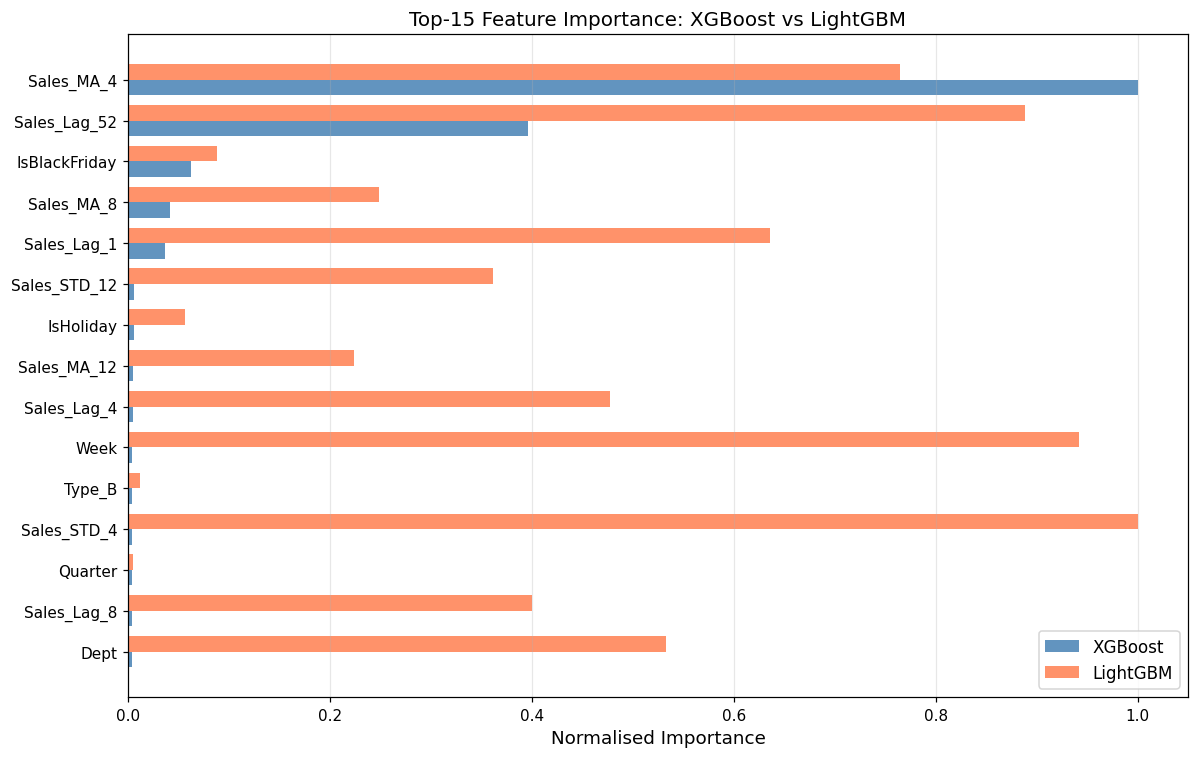

In [14]:
if lgbm_available:
    # Side-by-side feature importance comparison
    xgb_imp  = pd.Series(xgb.feature_importances_,  index=MODEL_FEATURES, name="XGBoost")
    lgbm_imp = pd.Series(lgbm.feature_importances_, index=MODEL_FEATURES, name="LightGBM")

    imp_df = pd.concat([xgb_imp, lgbm_imp], axis=1)
    imp_df = imp_df.sort_values("XGBoost", ascending=False).head(15)

    imp_df_norm = imp_df.div(imp_df.max())

    fig, ax = plt.subplots(figsize=(11, 7))
    x = np.arange(len(imp_df_norm))
    w = 0.38
    ax.barh(x - w/2, imp_df_norm["XGBoost"][::-1],  w, label="XGBoost",  color=PRIMARY_COLOR,   alpha=0.85)
    ax.barh(x + w/2, imp_df_norm["LightGBM"][::-1], w, label="LightGBM", color=SECONDARY_COLOR, alpha=0.85)
    ax.set_yticks(x)
    ax.set_yticklabels(imp_df_norm.index[::-1], fontsize=10)
    ax.set_xlabel("Normalised Importance", fontsize=12)
    ax.set_title("Top-15 Feature Importance: XGBoost vs LightGBM", fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## 5 · Save Models

In [15]:
import pickle

os.makedirs(os.path.dirname(XGB_FILE), exist_ok=True)

with open(XGB_FILE, "wb") as f:
    pickle.dump(xgb, f)
print(f"XGBoost saved : {XGB_FILE}")

if lgbm_available:
    with open(LGBM_FILE, "wb") as f:
        pickle.dump(lgbm, f)
    print(f"LightGBM saved: {LGBM_FILE}")

print("\nModel checkpoints saved. ✓")

XGBoost saved : /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_7_Sales_Forecasting/models/xgboost_model.pkl
LightGBM saved: /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_7_Sales_Forecasting/models/lgbm_model.pkl

Model checkpoints saved. ✓


---
## Summary

### Results — Per-Store-Department Level (37,865 test rows)

| Model | Train RMSE | Train R² | Val RMSE | Val R² | **Test RMSE** | **Test R²** |
|-------|-----------|----------|---------|--------|--------------|------------|
| XGBoost | $1,767 | 0.9941 | $2,273 | 0.9896 | **$2,176** | **0.9903** |
| LightGBM | $1,971 | 0.9926 | $2,246 | 0.9898 | **$2,177** | **0.9902** |

Both models are essentially tied — less than $1 difference in test RMSE.

### MAPE Caveat

The reported MAPE values (XGBoost: 99.4%, LightGBM: 78.4%) are **inflated by near-zero-sales
departments**. Some store-department combinations have weekly sales close to $0 (e.g., seasonal
departments in off-peak weeks, or departments with very low foot traffic). A $20 absolute error
on a $21 sale gives 95% MAPE, while RMSE = $20 and R² remain excellent.

**RMSE and R² are the reliable metrics for this task.** MAPE should be interpreted only for
departments with consistently substantial sales (> $1,000/week).

### Key Observations

- XGBoost ran all **500 iterations** without early stopping, suggesting the model was still
  marginally improving at that point. Increasing `n_estimators` or tuning further may help.
- LightGBM trains faster on the same data due to histogram-based splits.
- Both models show excellent generalisation: Train R² ≈ Test R² gap is only ~0.004.
- `Sales_Lag_52` and `Sales_MA_4` are consistently the top-ranked features.

**Next**: `06_evaluation.ipynb` — final comparison of all three models, actual vs predicted plots.